# Weather Trend Forecasting Assignment

## Importing Modules

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from datetime import datetime

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder

print("Modules Imported")

Modules Imported


## Importing Data

In [2]:
df = pd.read_csv("GlobalWeatherRepository.csv")

df

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.5200,69.1800,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,...,8.40,26.60,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.3300,19.8200,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,...,1.10,2.00,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.7600,3.0500,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,...,10.40,18.40,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.5000,1.5200,Europe/Andorra,1715849100,2024-05-16 10:45,6.3,43.3,Light drizzle,...,0.70,0.90,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.8400,13.2300,Africa/Luanda,1715849100,2024-05-16 09:45,26.0,78.8,Partly cloudy,...,183.40,262.30,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140918,Venezuela,Caracas,10.5000,-66.9167,America/Caracas,1778567400,2026-05-12 02:30,18.3,64.9,Patchy rain nearby,...,8.95,11.75,1,1,06:06 AM,06:42 PM,02:31 AM,02:51 PM,Waning Crescent,27
140919,Vietnam,Hanoi,21.0333,105.8500,Asia/Bangkok,1778567400,2026-05-12 13:30,32.3,90.1,Partly cloudy,...,43.55,46.05,3,5,05:21 AM,06:26 PM,01:46 AM,01:54 PM,Waning Crescent,32
140920,Yemen,Sanaa,15.3547,44.2067,Asia/Aden,1778567400,2026-05-12 09:30,20.8,69.4,Sunny,...,12.15,41.85,1,2,05:36 AM,06:24 PM,01:57 AM,02:11 PM,Waning Crescent,30
140921,Zambia,Lusaka,-15.4167,28.2833,Africa/Lusaka,1778567400,2026-05-12 08:30,21.2,70.1,Sunny,...,7.45,7.65,1,1,06:20 AM,05:46 PM,01:52 AM,02:19 PM,Waning Crescent,30


## Data Analysis

In [3]:
df.columns

Index(['country', 'location_name', 'latitude', 'longitude', 'timezone',
       'last_updated_epoch', 'last_updated', 'temperature_celsius',
       'temperature_fahrenheit', 'condition_text', 'wind_mph', 'wind_kph',
       'wind_degree', 'wind_direction', 'pressure_mb', 'pressure_in',
       'precip_mm', 'precip_in', 'humidity', 'cloud', 'feels_like_celsius',
       'feels_like_fahrenheit', 'visibility_km', 'visibility_miles',
       'uv_index', 'gust_mph', 'gust_kph', 'air_quality_Carbon_Monoxide',
       'air_quality_Ozone', 'air_quality_Nitrogen_dioxide',
       'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10',
       'air_quality_us-epa-index', 'air_quality_gb-defra-index', 'sunrise',
       'sunset', 'moonrise', 'moonset', 'moon_phase', 'moon_illumination'],
      dtype='object')

Remove features that have pair metrics: **temperature_fahrenheit, feels_like_fahrenheit, visibility_miles, gust_mph, precip_in, pressure_in, wind_mph, last_updated_epoch**

In [4]:
filtered_df = df.copy()
filtered_df = df.drop(columns=["temperature_fahrenheit", "feels_like_fahrenheit", "visibility_miles", "gust_mph", "precip_in", "pressure_in", "wind_mph", "last_updated_epoch"])

filtered_df.columns

Index(['country', 'location_name', 'latitude', 'longitude', 'timezone',
       'last_updated', 'temperature_celsius', 'condition_text', 'wind_kph',
       'wind_degree', 'wind_direction', 'pressure_mb', 'precip_mm', 'humidity',
       'cloud', 'feels_like_celsius', 'visibility_km', 'uv_index', 'gust_kph',
       'air_quality_Carbon_Monoxide', 'air_quality_Ozone',
       'air_quality_Nitrogen_dioxide', 'air_quality_Sulphur_dioxide',
       'air_quality_PM2.5', 'air_quality_PM10', 'air_quality_us-epa-index',
       'air_quality_gb-defra-index', 'sunrise', 'sunset', 'moonrise',
       'moonset', 'moon_phase', 'moon_illumination'],
      dtype='object')

In [5]:
filtered_df.describe()

,latitude,longitude,temperature_celsius,wind_kph,wind_degree,pressure_mb,precip_mm,humidity,cloud,feels_like_celsius,...,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,moon_illumination
count,140923.000000,140923.000000,140923.000000,140923.000000,140923.000000,140923.000000,140923.00000,140923.000000,140923.000000,140923.000000,...,140923.000000,140923.000000,140923.000000,140923.000000,140923.000000,140923.000000,140923.000000,140923.000000,140923.000000,140923.000000
mean,19.216241,21.940633,21.243149,12.857221,168.800685,1014.053292,0.13317,66.731733,39.847009,22.096876,...,18.192991,452.961460,57.731223,14.864649,10.178871,23.924115,47.854728,1.689582,2.583056,50.079348
std,24.413082,65.783983,9.650904,11.492508,103.725086,10.215805,0.55709,23.813318,34.085906,11.554897,...,13.712501,747.410497,30.513048,23.431508,35.009131,36.373748,147.491532,0.934690,2.426315,35.024991
min,-41.300000,-175.200000,-29.800000,3.600000,1.000000,947.000000,0.00000,2.000000,0.000000,-36.700000,...,3.600000,-9999.000000,0.000000,0.000000,-9999.000000,0.168000,-1848.150000,1.000000,1.000000,0.000000
25%,4.050300,-6.836100,15.600000,6.100000,80.000000,1010.000000,0.00000,51.000000,0.000000,15.700000,...,10.200000,197.850000,38.000000,1.750000,1.110000,7.030000,9.850000,1.000000,1.000000,15.000000
50%,17.250000,23.236100,23.800000,10.800000,161.000000,1013.000000,0.00000,72.000000,29.000000,25.100000,...,15.300000,288.850000,55.000000,5.700000,2.405000,14.050000,19.750000,1.000000,2.000000,50.000000
75%,40.400000,49.882200,28.000000,17.600000,256.000000,1018.000000,0.02000,86.000000,75.000000,29.900000,...,24.100000,454.000000,73.000000,17.205000,8.140000,27.450000,41.050000,2.000000,3.000000,85.000000
max,64.150000,179.220000,79.300000,2963.200000,360.000000,3006.000000,42.24000,100.000000,100.000000,81.300000,...,2970.400000,38879.398000,480.700000,427.700000,521.330000,1614.100000,6037.290000,6.000000,10.000000,100.000000


In [6]:
filtered_df = filtered_df.rename(columns = {
    'condition_text':'y'
})

Naming the label as "y", to facilitate further processes

In [7]:
filtered_df[filtered_df.isna().any(axis=1)]

,country,location_name,latitude,longitude,timezone,last_updated,temperature_celsius,y,wind_kph,wind_degree,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination


No NaN value

In [8]:
filtered_df[filtered_df.isnull().any(axis=1)]

,country,location_name,latitude,longitude,timezone,last_updated,temperature_celsius,y,wind_kph,wind_degree,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination


No Null value

In [9]:
filtered_df["y"] = filtered_df["y"].str.strip().str.lower()

Normalizing "y" text. Removing additional whitespace and lowercasing all.

In [10]:
top_y = filtered_df["y"].value_counts().nlargest(15).index

graph_df = filtered_df.copy()

# If NOT on the top y, is rest
graph_df["y"] = filtered_df["y"].apply(
    lambda x: x if x in top_y else "rest"
)

graph_df["y"].value_counts().nlargest(15)

y
partly cloudy                          49342
sunny                                  40554
patchy rain nearby                     11788
overcast                                7663
clear                                   7545
mist                                    5892
light rain                              4403
light rain shower                       3212
rest                                    2780
fog                                     1749
cloudy                                  1702
moderate or heavy rain with thunder     1126
moderate rain                           1063
patchy light rain with thunder           874
light drizzle                            705
Name: count, dtype: int64

Categorizing all weather categories outside the top 15 most common values to be considered in a group called "rest"

### Weather Distribution Graph

Text(0, 0.5, 'Number of records')

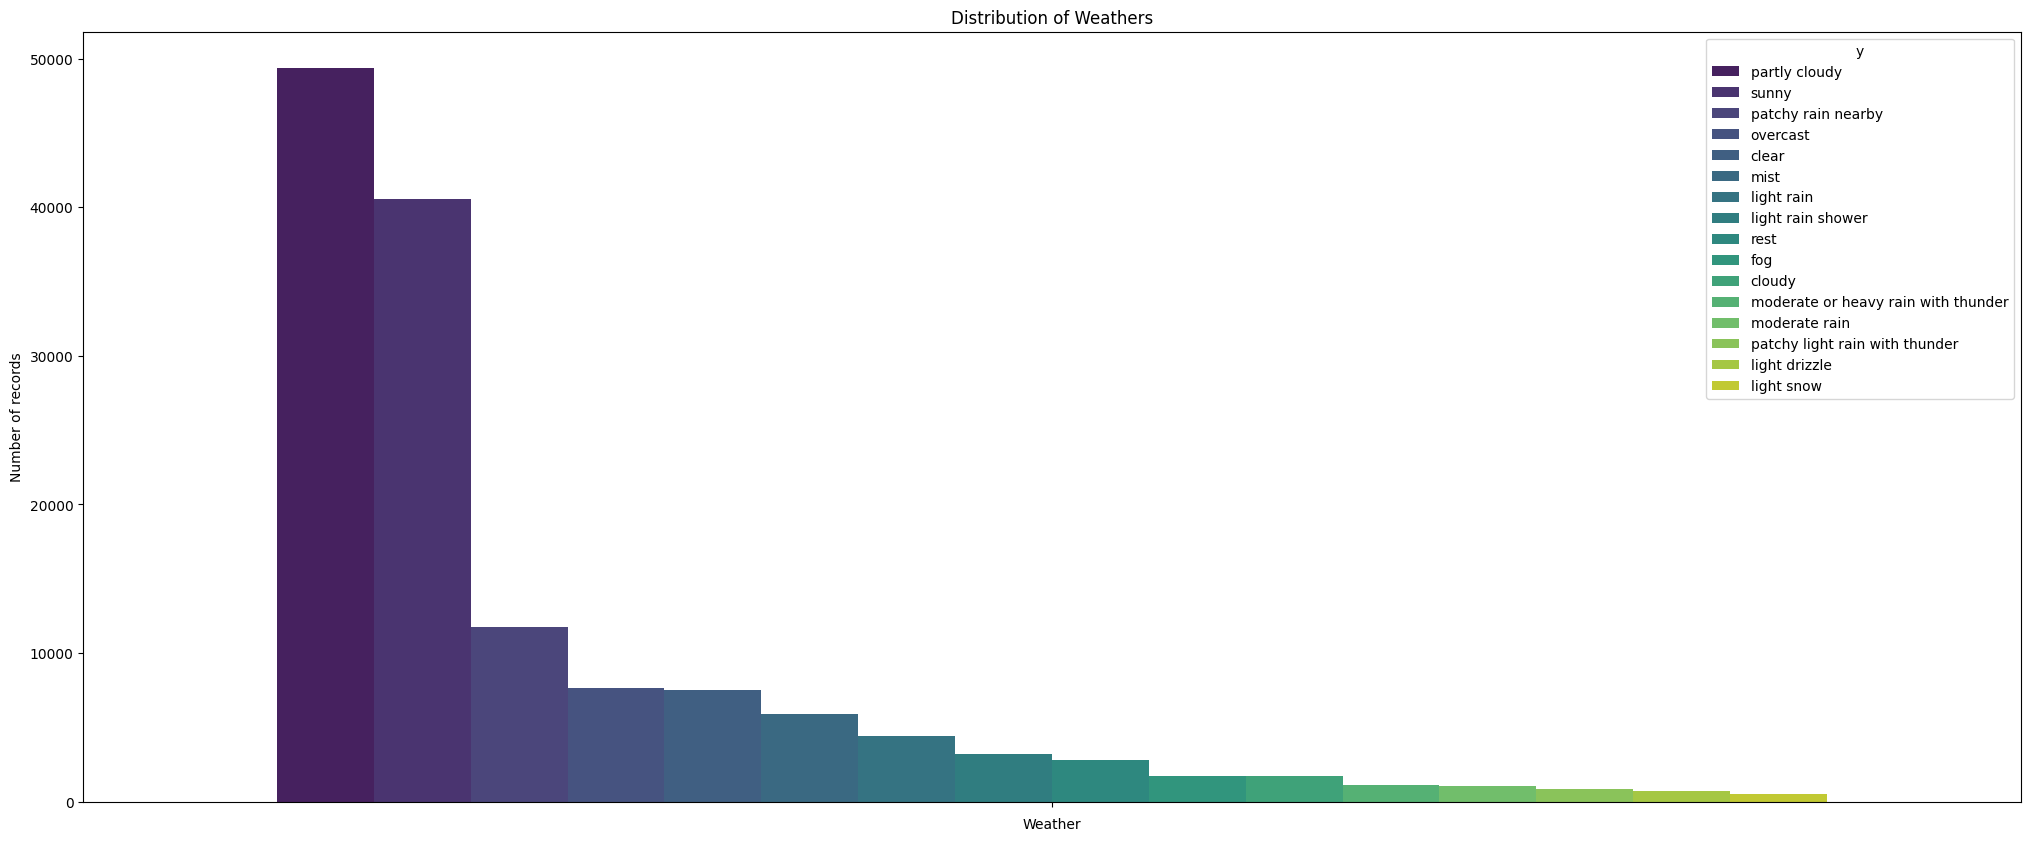

In [11]:
weather_count = graph_df["y"].value_counts()

fig, ax = plt.subplots(1, 1, figsize=(25,10))

sns.barplot(y=weather_count.values, hue=weather_count.index, ax=ax, palette="viridis")
ax.set_title("Distribution of Weathers")
ax.set_xlabel("Weather")
ax.tick_params(axis='x', labelrotation=90)
ax.set_ylabel("Number of records")

### Country Distribuition Graph

### Distribution of Temperature by Weather

Text(0, 0.5, 'Temperature (°C)')

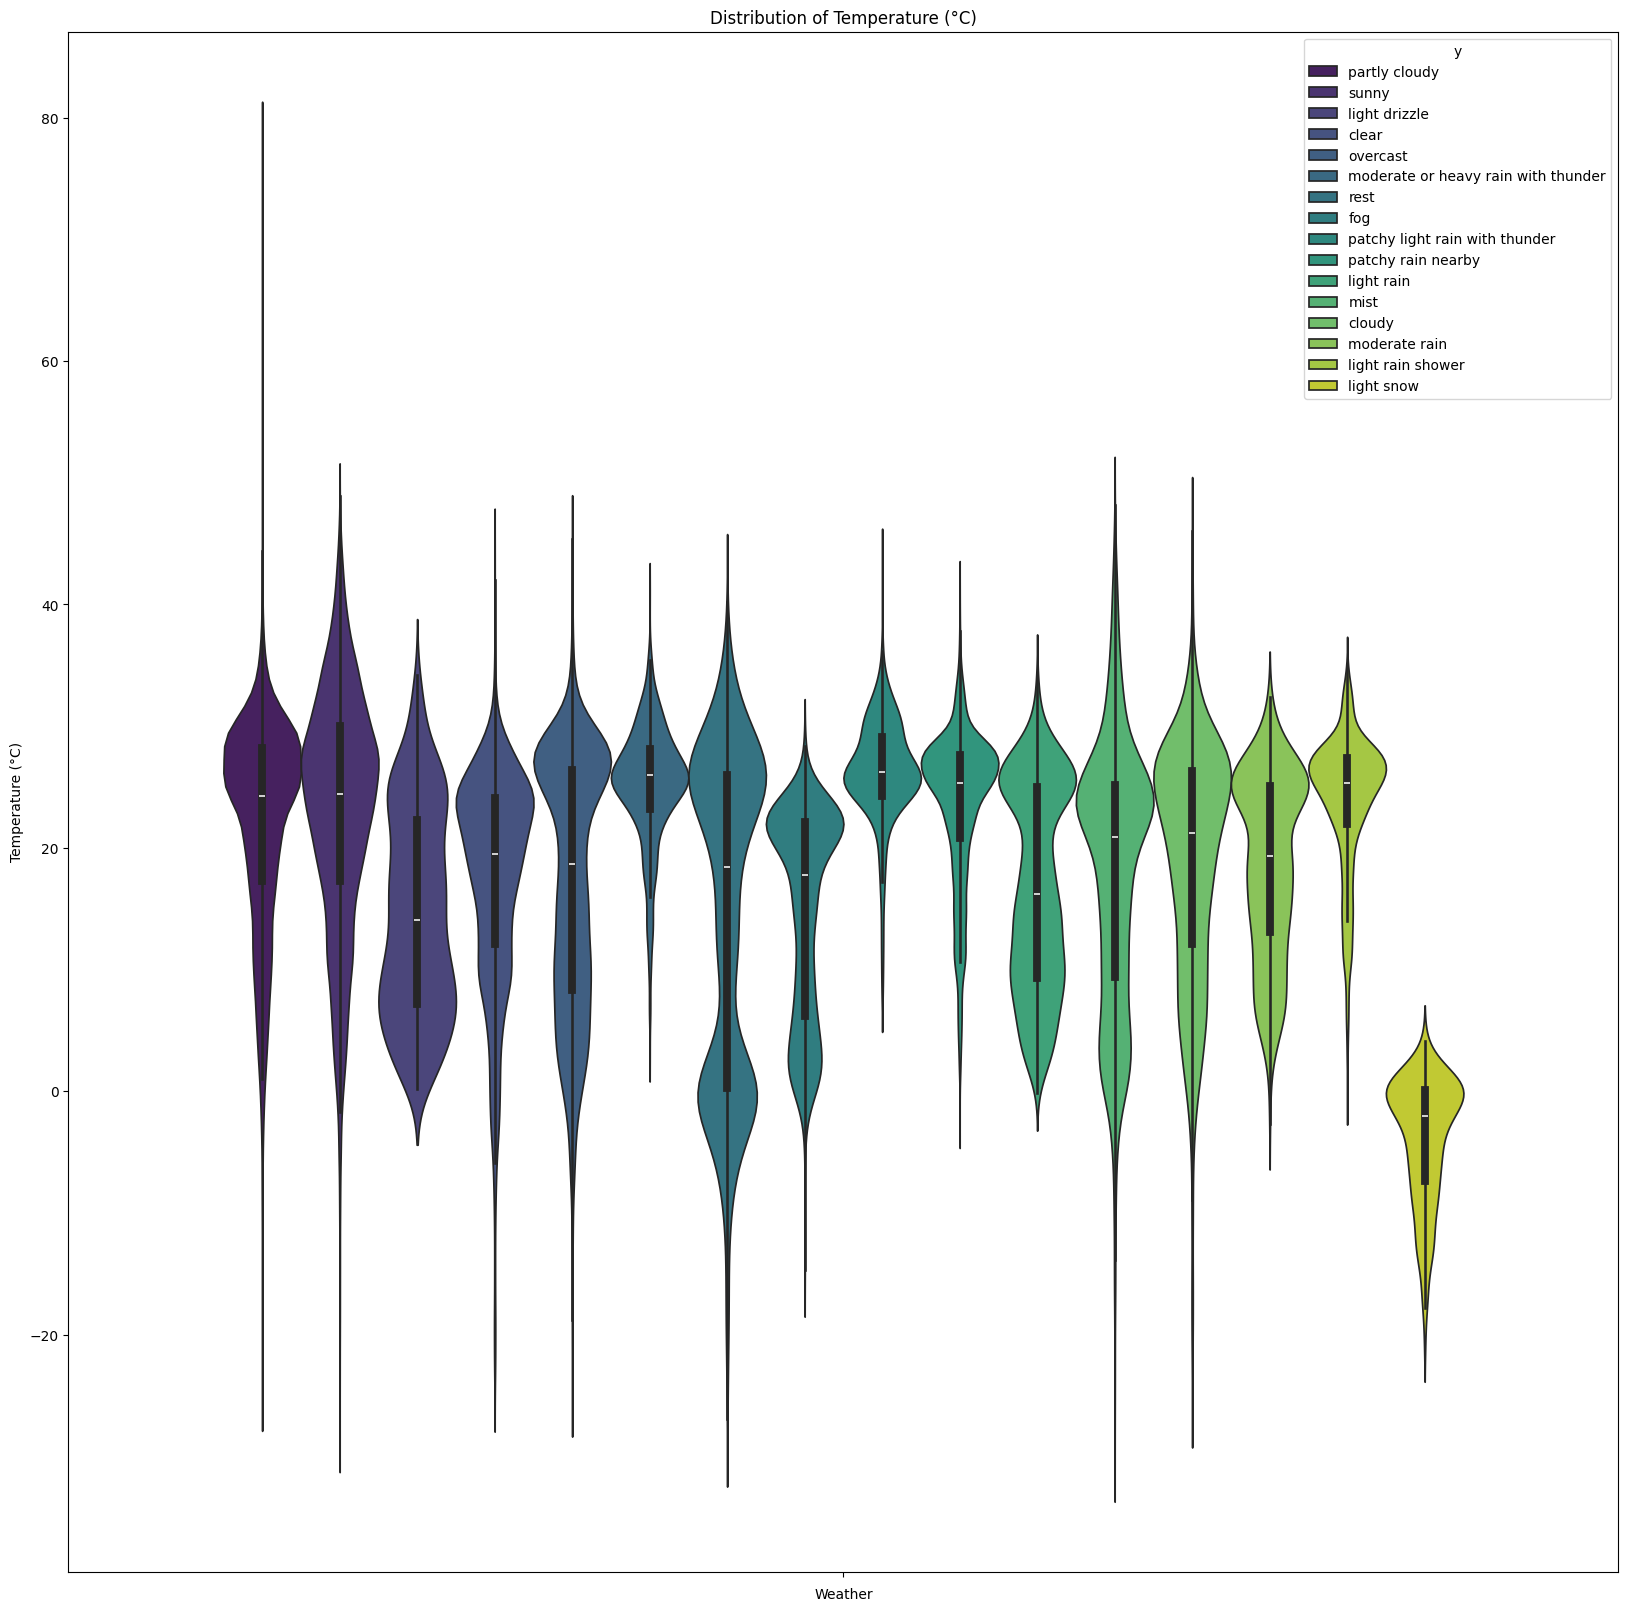

In [12]:
fig, ax = plt.subplots(1,1, figsize=(20,20))

sns.violinplot(data=graph_df, y="temperature_celsius", hue="y" , ax=ax, palette="viridis")
ax.set_title("Distribution of Temperature (°C)")
ax.set_xlabel("Weather")
ax.tick_params(axis='x', labelrotation=90)
ax.set_ylabel("Temperature (°C)")

### Distribution of Precipitation by Weather

C:\Users\User\AppData\Local\Temp\ipykernel_1672\1497072071.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=graph_df, y="y", x="precip_mm", ax=ax, palette="viridis")


Text(0.5, 0, 'Precipitation (mm)')

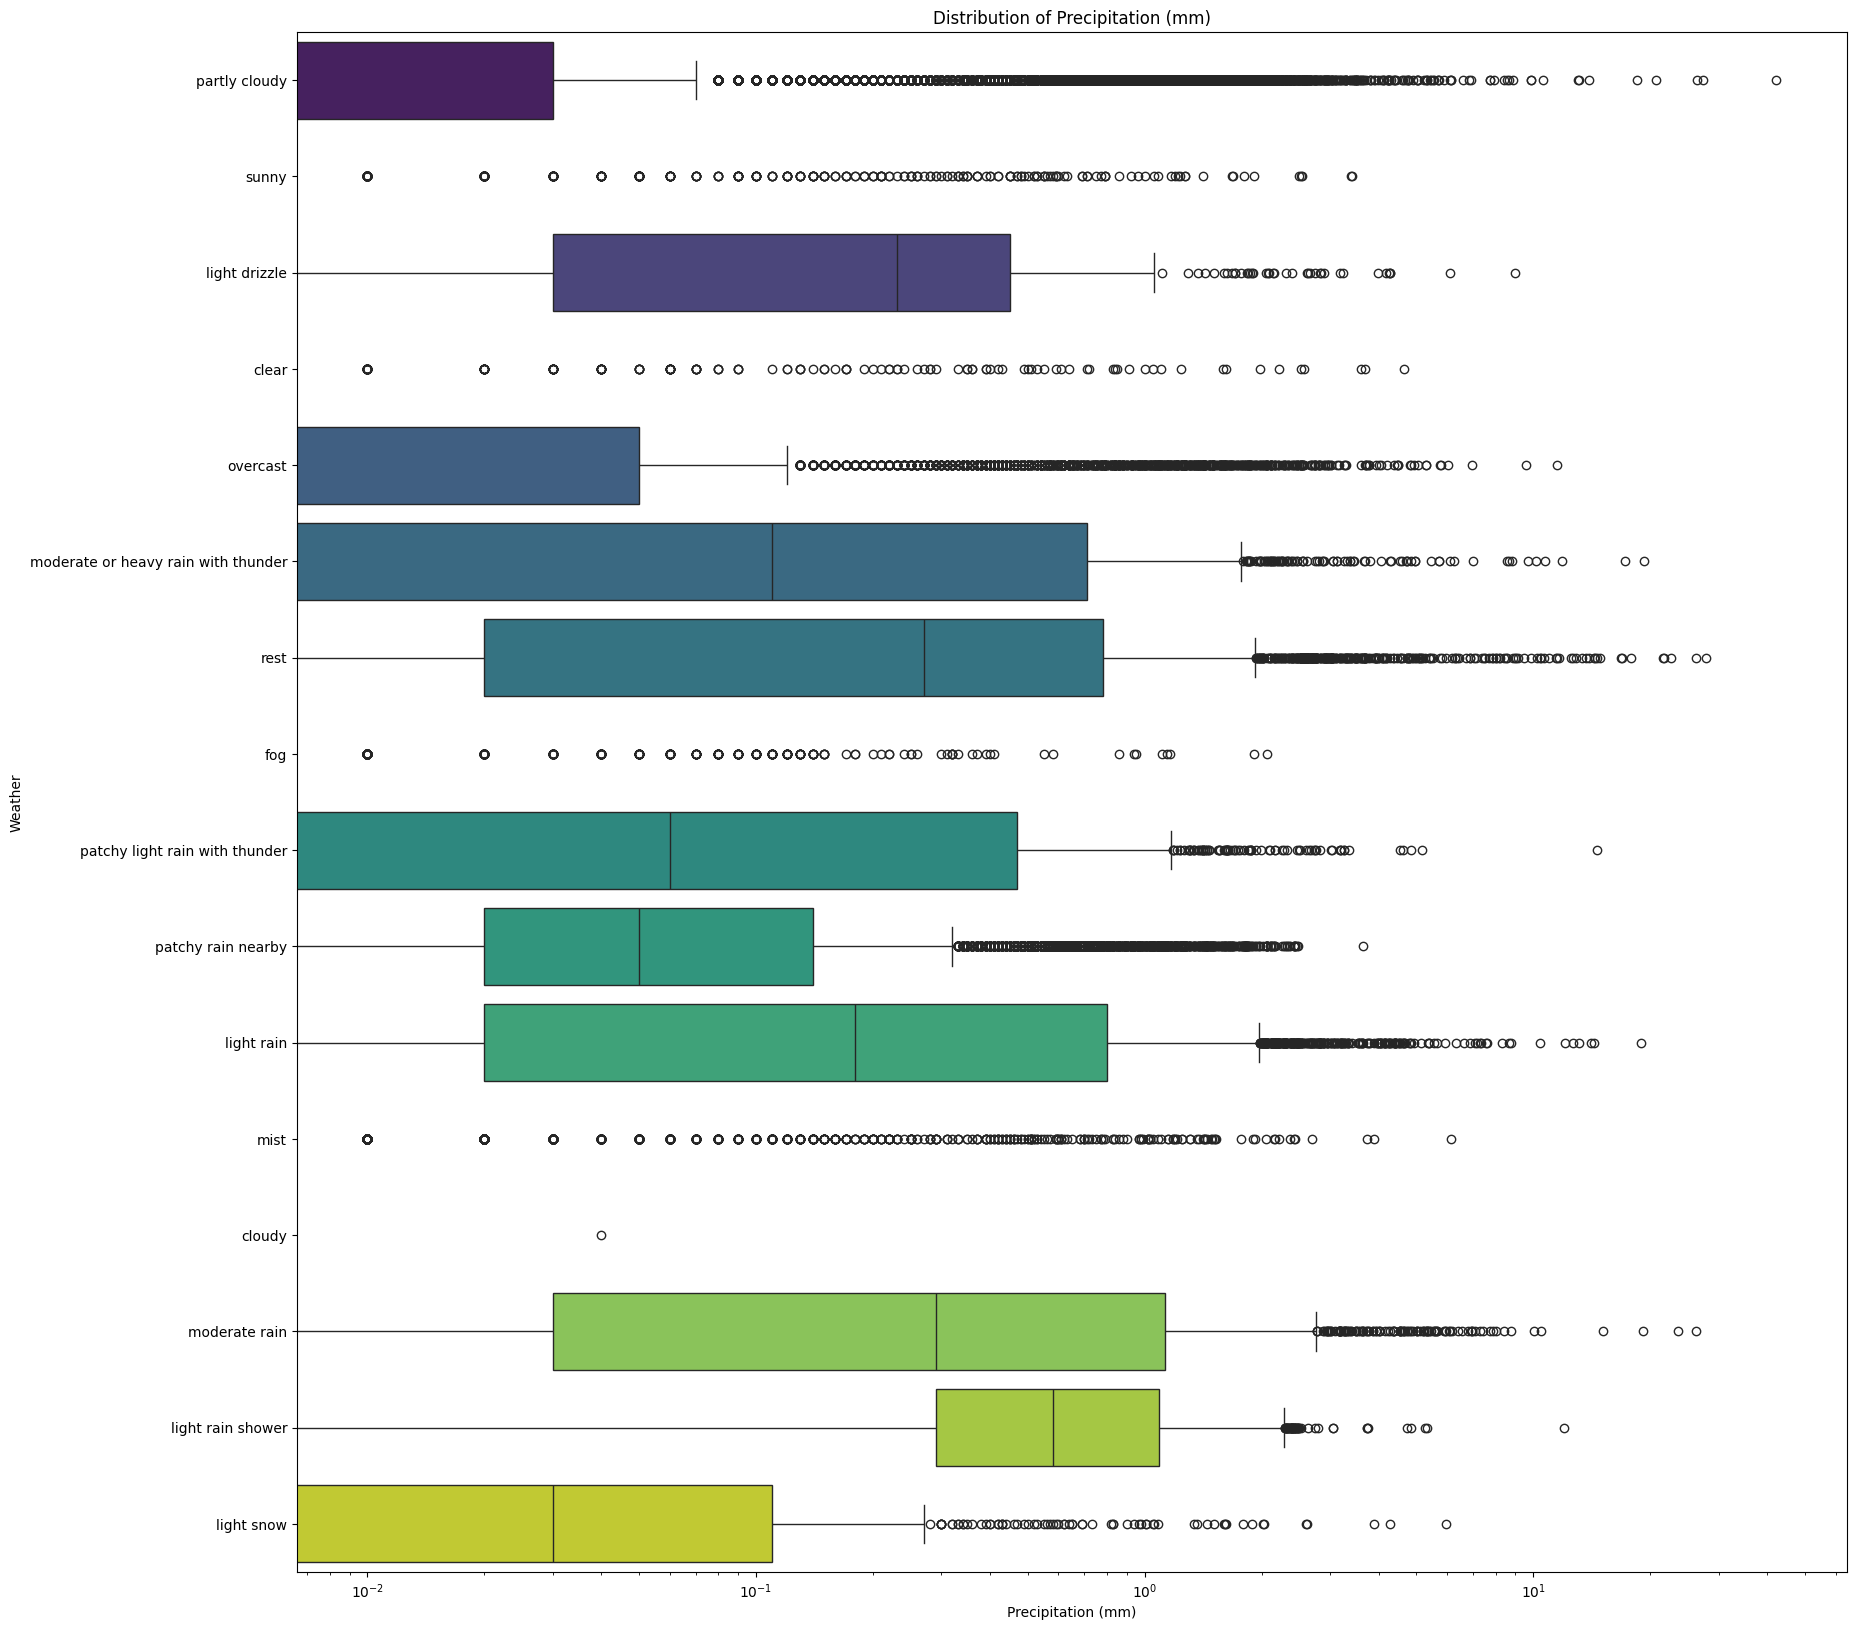

In [13]:
fig, ax = plt.subplots(1,1, figsize=(20,20))

sns.boxplot(data=graph_df, y="y", x="precip_mm", ax=ax, palette="viridis")

ax.set_title("Distribution of Precipitation (mm)")
ax.set_ylabel("Weather")
ax.set_xscale("log")
ax.set_xlabel("Precipitation (mm)")

### Correlation of Humidity by Temperature

Text(0.5, 0, 'Humidity (%)')

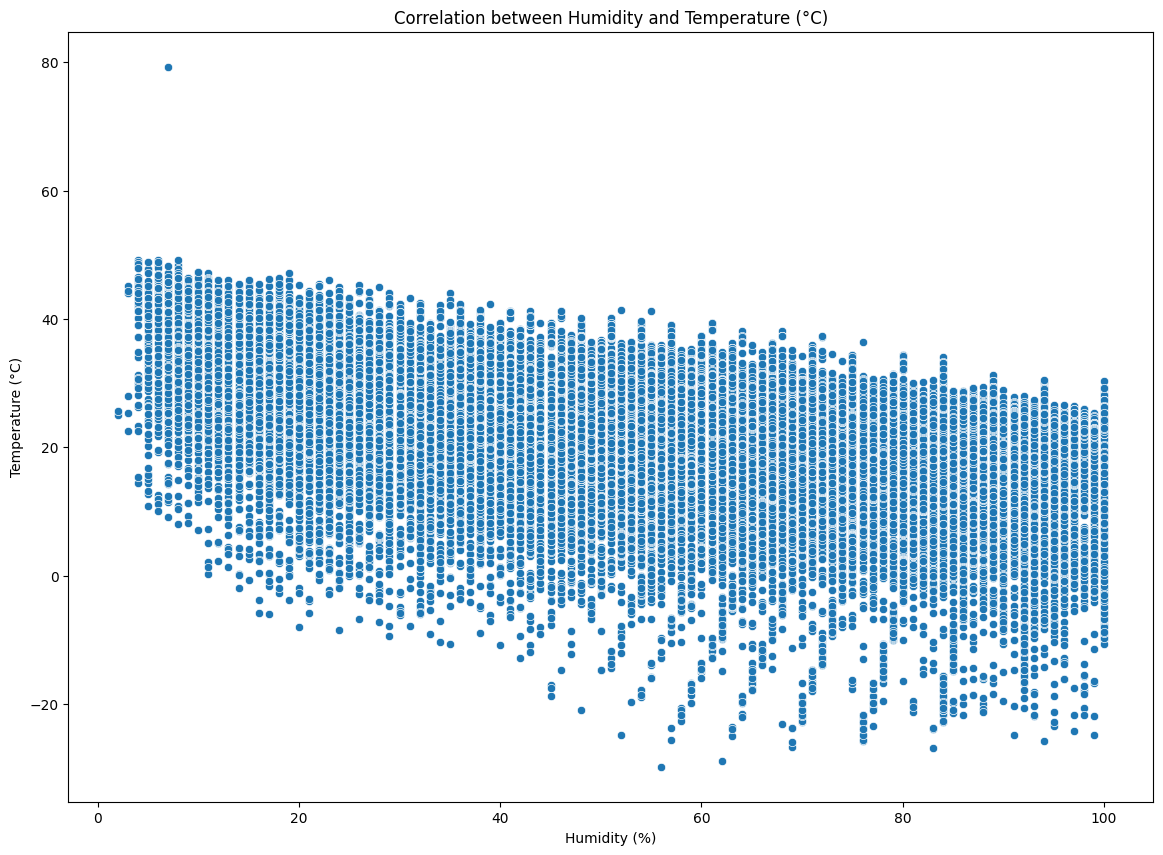

In [14]:
fig, ax = plt.subplots(1,1, figsize=(14,10))

sns.scatterplot(data=graph_df, x="humidity", y="temperature_celsius")
ax.set_title("Correlation between Humidity and Temperature (°C)")
ax.set_ylabel("Temperature (°C)")
ax.set_xlabel("Humidity (%)")

### Correlation of Precipitation by Temperature

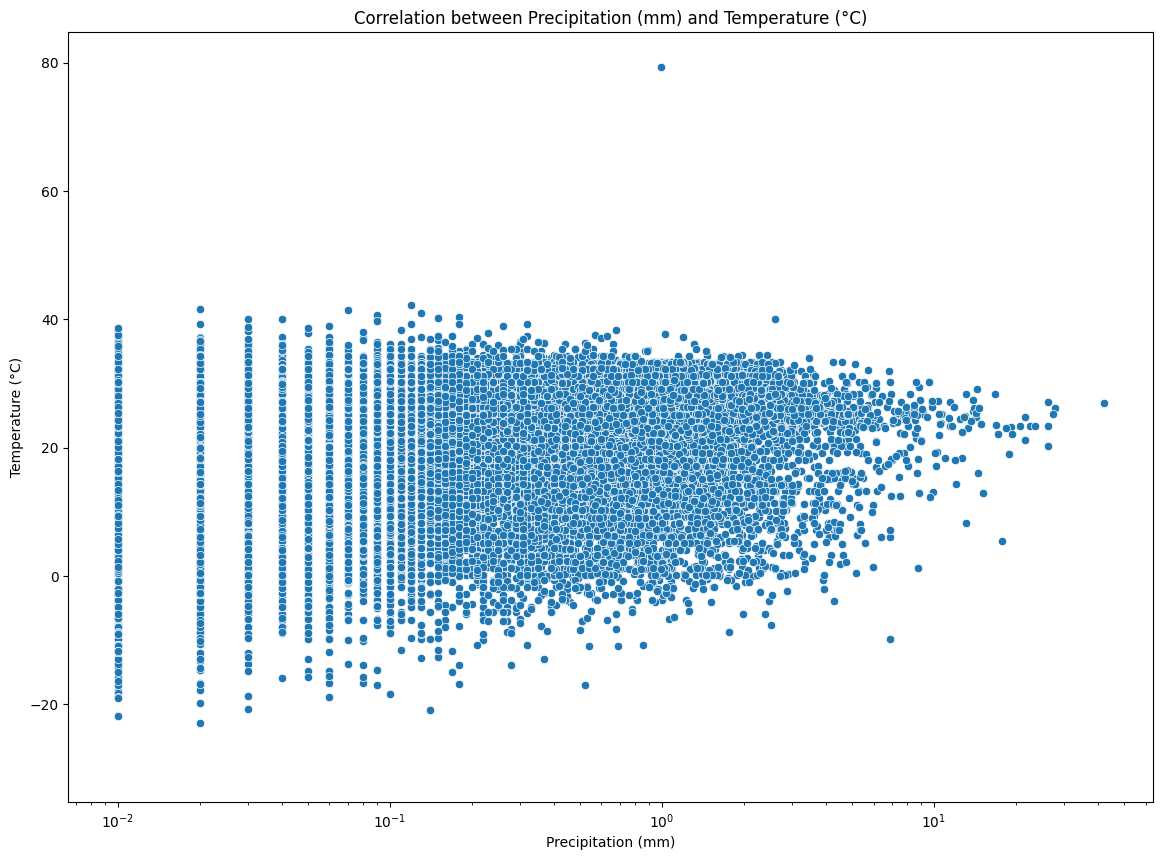

In [15]:
fig, ax = plt.subplots(1,1, figsize=(14,10))

sns.scatterplot(data=graph_df, x="precip_mm", y="temperature_celsius")
ax.set_title("Correlation between Precipitation (mm) and Temperature (°C)")
ax.set_ylabel("Temperature (°C)")
ax.set_xlabel("Precipitation (mm)")
ax.set_xscale("log")

### Correlation of Wind Speed (Kph) by Precipitation (mm)

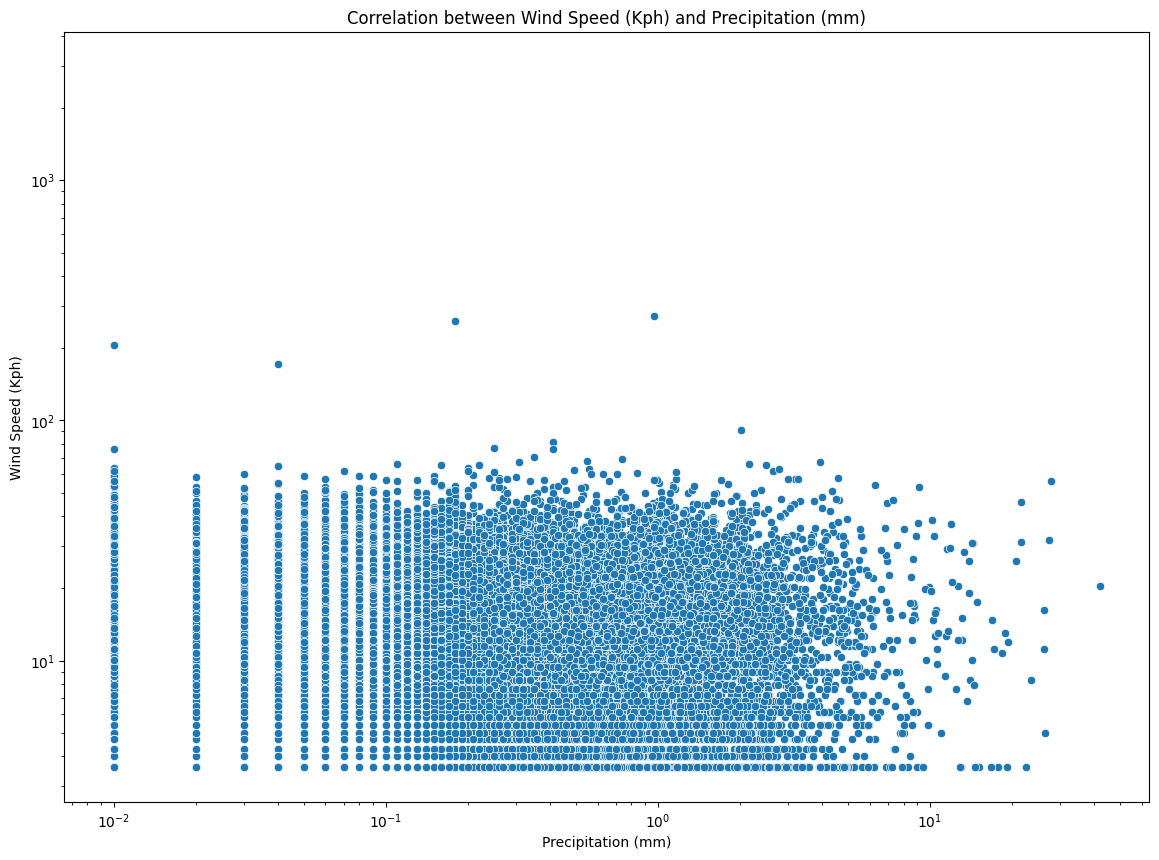

In [16]:
fig, ax = plt.subplots(1,1, figsize=(14,10))

sns.scatterplot(data=graph_df, y="wind_kph", x="precip_mm")
ax.set_title("Correlation between Wind Speed (Kph) and Precipitation (mm)")
ax.set_ylabel("Wind Speed (Kph)")
ax.set_yscale("log")
ax.set_xlabel("Precipitation (mm)")
ax.set_xscale("log")

### Correlation between Air Quality and Precipitation

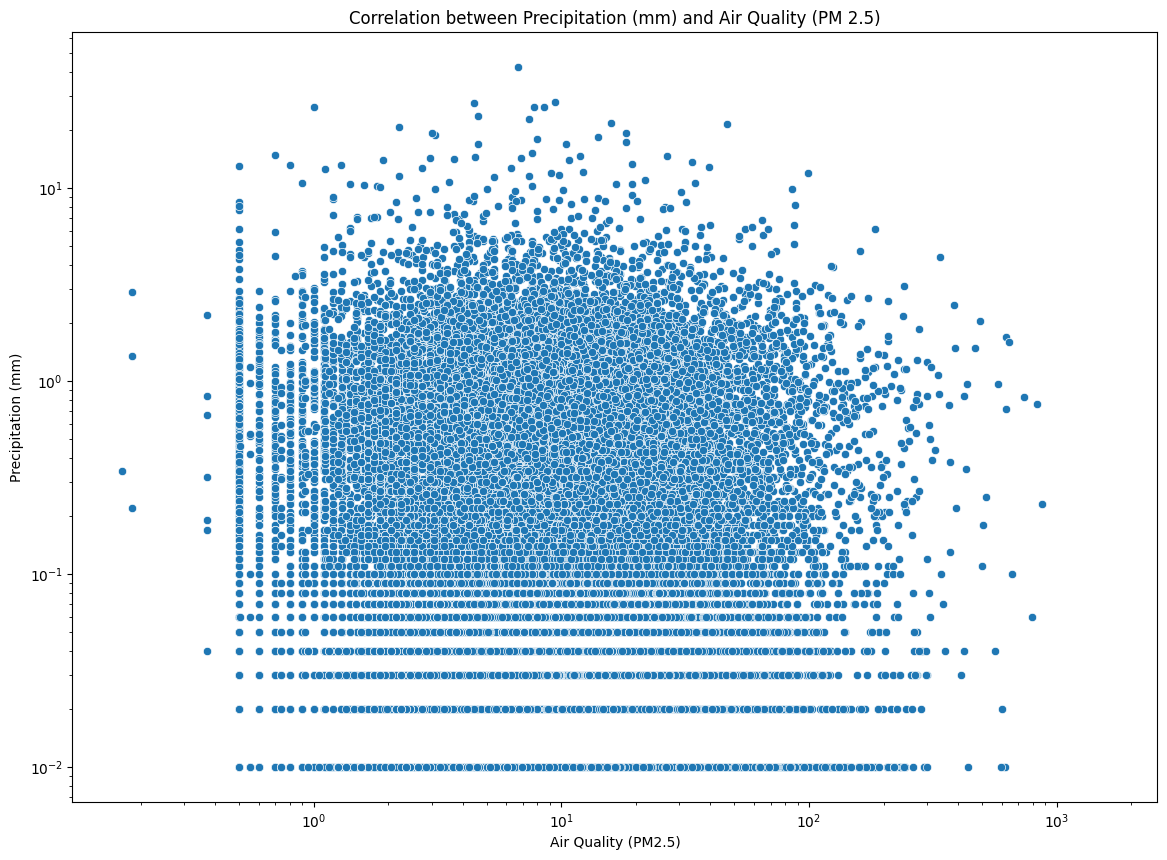

In [17]:
fig, ax = plt.subplots(1,1, figsize=(14,10))

sns.scatterplot(data=graph_df, y="precip_mm", x="air_quality_PM2.5")
ax.set_title("Correlation between Precipitation (mm) and Air Quality (PM 2.5)")
ax.set_ylabel("Precipitation (mm)")
ax.set_yscale("log")
ax.set_xlabel("Air Quality (PM2.5)")
ax.set_xscale("log")

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(14,10))

sns.scatterplot(data=graph_df, y="precip_mm", x="air_quality_Ozone")
ax.set_title("Correlation between Precipitation (mm) and Air Quality (Ground-level Ozone)")
ax.set_ylabel("Precipitation (mm)")
ax.set_yscale("log")
ax.set_xlabel("Air Quality (Ground-level Ozone)")
ax.set_xscale("log")

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(14,10))

sns.scatterplot(data=graph_df, y="precip_mm", x="air_quality_Carbon_Monoxide")
ax.set_title("Correlation between Precipitation (mm) and Air Quality (Carbon monoxide CO)")
ax.set_ylabel("Precipitation (mm)")
ax.set_yscale("log")
ax.set_xlabel("Air Quality (Carbon monoxide CO)")
ax.set_xscale("log")

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(14,10))

sns.scatterplot(data=graph_df, y="precip_mm", x="air_quality_Sulphur_dioxide")
ax.set_title("Correlation between Precipitation (mm) and Air Quality (Sulfur dioxide SO2)")
ax.set_ylabel("Precipitation (mm)")
ax.set_yscale("log")
ax.set_xlabel("Air Quality (Sulfur dioxide SO2)")
ax.set_xscale("log")

## Normalizing Data

Location and Country can be removed for some reasons, the first being the impracticality of encoding them, and all the geological information about it can be gathered from the latitude and longitude.

In [ ]:
filtered_df = filtered_df.drop(columns=["location_name", "country", "timezone", 'wind_direction'])

In [ ]:
time_features = ["sunrise", "sunset", "moonrise", "moonset"]

In [ ]:
def cyclic_encode(series, period):
    radians = 2 * np.pi * series / period

    sin = np.sin(radians)
    cos = np.cos(radians)

    return sin, cos

In [ ]:
def transform_data_set(dataframe, property_name, period):
    
    dataframe[f"{property_name}_sin"], dataframe[f"{property_name}_cos"] = cyclic_encode(
    dataframe[property_name],
    period
    )
    
    dataframe = dataframe.drop(columns=[property_name])
    
    return dataframe

In [ ]:
filtered_df["last_updated"] = pd.to_datetime(filtered_df["last_updated"])

In [ ]:
filtered_df["year"] = filtered_df["last_updated"].dt.year

filtered_df["year"].value_counts().index

In [ ]:
filtered_df["month"] = filtered_df["last_updated"].dt.month

In [ ]:
filtered_df["day_of_year"] = filtered_df["last_updated"].dt.day

In [ ]:
filtered_df["hour"] = filtered_df["last_updated"].dt.hour

In [ ]:
filtered_df = filtered_df.drop(columns=["last_updated"])

In [ ]:
for time in time_features:
    parsed_time = pd.to_datetime(
        filtered_df[time],
        format="%I:%M %p",
        errors="coerce"
    )

    filtered_df[time] = (
        parsed_time.dt.hour +
        parsed_time.dt.minute / 60
    )

    filtered_df = transform_data_set(filtered_df, time, 24)

In [ ]:
filtered_df = transform_data_set(filtered_df, "wind_degree", 24)

In [ ]:
filtered_df = transform_data_set(filtered_df, "hour", 24)

In [ ]:
filtered_df = transform_data_set(filtered_df, "month", 12)

In [ ]:
filtered_df.columns

In [ ]:
for col in filtered_df.columns:
    print(type(filtered_df[col].iloc[0]))

### Encoding Values

In [ ]:
ohe = OneHotEncoder(sparse_output=False).set_output(transform='pandas')
le = LabelEncoder()

In [ ]:
filtered_df['y'] = le.fit_transform(filtered_df['y'])

In [ ]:
encoded_moon_phase = ohe.fit_transform(filtered_df[['moon_phase']])

filtered_df = pd.concat(
    [filtered_df.drop(columns=['moon_phase']), encoded_moon_phase],
    axis=1
)

In [ ]:
for col in filtered_df.columns:
    print(type(filtered_df[col].iloc[0]))

All values are transformed in numeric values

## Outliers

In [ ]:
iso_forest = IsolationForest(contamination=0.02)
iso_forest.fit(filtered_df)
predictions = iso_forest.predict(filtered_df)

In [ ]:
graph_df['is_outlier'] = predictions

outliers = graph_df[graph_df['is_outlier'] == -1]

weather_total_count = graph_df["y"].value_counts()
weather_count_outliers = outliers["y"].value_counts()

outlier_ratio = (weather_count_outliers / weather_total_count) * 100
outlier_ratio = outlier_ratio.fillna(0)

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(25,10))

sns.barplot(y=outlier_ratio.values, hue=outlier_ratio.index, ax=ax, palette="viridis")
ax.set_title("Distribution Outliers by Weathers")
ax.set_xlabel("Weather")
ax.set_ylabel("Outliers proportions (%)")

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(14,10))

sns.scatterplot(data=graph_df[graph_df['is_outlier'] == 1], x="precip_mm", y="temperature_celsius")
sns.scatterplot(data=graph_df[graph_df['is_outlier'] == -1], x="precip_mm", y="temperature_celsius", color='red')
ax.set_title("Correlation between Precipitation (mm) and Temperature (°C)")
ax.set_ylabel("Temperature (°C)")
ax.set_xlabel("Precipitation (mm)")
ax.set_xscale("log")

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(20,20))

sns.violinplot(
    data=graph_df,
    x="y",
    y="temperature_celsius",
    ax=ax,
    palette="viridis",
    inner=None
)

sns.scatterplot(
    data=graph_df[graph_df['is_outlier'] == -1],
    x="y",
    y="temperature_celsius",
    color="red",
    ax=ax
)

ax.set_title("Distribution of Temperature (°C)")
ax.set_xlabel("Weather")
ax.tick_params(axis='x', labelrotation=90)
ax.set_ylabel("Temperature (°C)")

## Splitting the Data

In [ ]:
filtered_df.columns

In [ ]:
X = filtered_df.drop('y')